# Handling Imbalanced Data in Machine Learning

## 1. What is Imbalanced Data
- Occurs when one class has significantly more samples than others.
- Common in fraud detection, medical diagnosis, etc.
- Problem: Models favor the majority class, ignoring minority.

## 2. Identifying Imbalance
```python
import pandas as pd
df = pd.read_csv("data.csv")
print(df['target'].value_counts())

| Method                  | Description                               | Pros                    | Cons                      |
|-------------------------|-------------------------------------------|------------------------|---------------------------|
| Oversampling (SMOTE)    | Generate synthetic minority samples       | Improves recall        | Risk of overfitting       |
| Undersampling           | Reduce majority samples                   | Simple, fast           | May lose information      |
| Class weighting         | Penalize misclassification of minority   | Easy to implement      | Needs careful tuning      |
| Ensemble methods        | Combine multiple models                   | Robust                 | Complex                   |
| Anomaly detection       | Treat minority class as anomaly           | Good for extreme cases | Limited to rare cases     |
| Evaluation Metrics      | Use F1, ROC-AUC, PR-AUC instead of acc   | Better model assessment| None                      |

Original class distribution:
0    950
1     50
Name: count, dtype: int64

After SMOTE oversampling:
0    665
1    665
Name: count, dtype: int64

After Random Undersampling:
0    35
1    35
Name: count, dtype: int64

After SMOTE + ENN (hybrid):
1    665
0    659
Name: count, dtype: int64

Classification Report (Class Weight):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       285
           1       1.00      0.67      0.80        15

    accuracy                           0.98       300
   macro avg       0.99      0.83      0.90       300
weighted avg       0.98      0.98      0.98       300


Classification Report (SMOTE):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       285
           1       0.86      0.80      0.83        15

    accuracy                           0.98       300
   macro avg       0.92      0.90      0.91       300
weighted avg       0.98      0.98      0.9

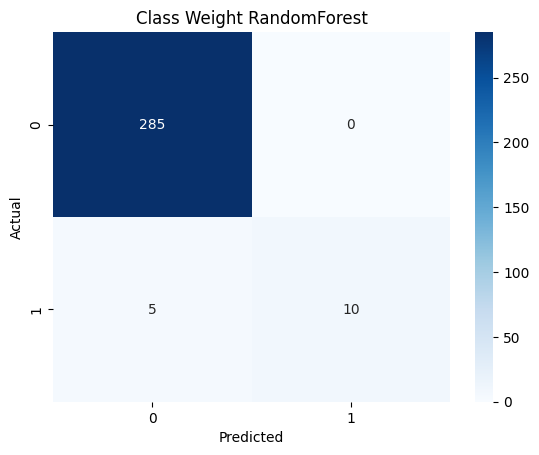

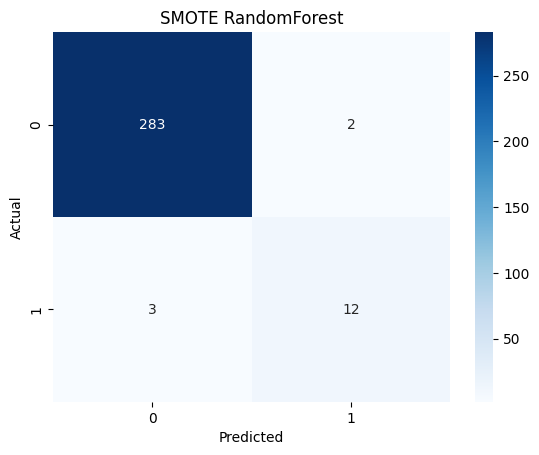

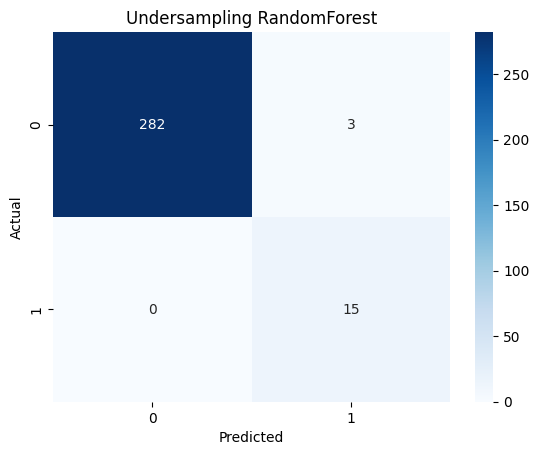

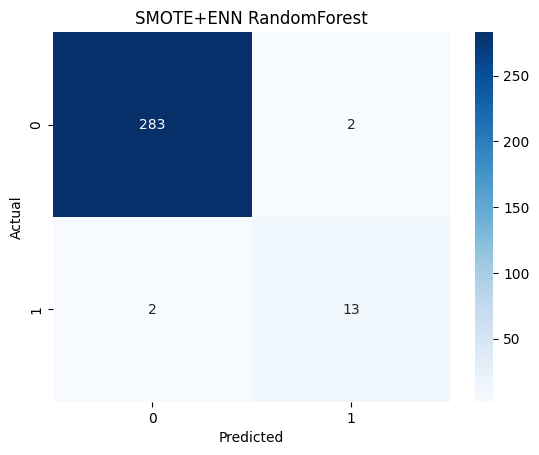

In [3]:
#%pip install imbalanced-learn

# Imbalanced Data Handling Example in Python

import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

# 1️⃣ Create Imbalanced Dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, 
                           n_redundant=2, n_clusters_per_class=1,
                           weights=[0.95], flip_y=0, random_state=42)

print("Original class distribution:")
print(pd.Series(y).value_counts())

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2️⃣ Handle Imbalance

## A. Oversampling (SMOTE)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE oversampling:")
print(pd.Series(y_smote).value_counts())

## B. Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print("\nAfter Random Undersampling:")
print(pd.Series(y_rus).value_counts())

## C. Combination (SMOTE + ENN)
smote_enn = SMOTEENN(random_state=42)
X_combo, y_combo = smote_enn.fit_resample(X_train, y_train)
print("\nAfter SMOTE + ENN (hybrid):")
print(pd.Series(y_combo).value_counts())

# 3️⃣ Model Training

## Using class_weight for imbalance
clf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42)
clf_weighted.fit(X_train, y_train)
y_pred_weighted = clf_weighted.predict(X_test)
print("\nClassification Report (Class Weight):")
print(classification_report(y_test, y_pred_weighted))

## Using SMOTE data
clf_smote = RandomForestClassifier(random_state=42)
clf_smote.fit(X_smote, y_smote)
y_pred_smote = clf_smote.predict(X_test)
print("\nClassification Report (SMOTE):")
print(classification_report(y_test, y_pred_smote))

## Using Undersampled data
clf_rus = RandomForestClassifier(random_state=42)
clf_rus.fit(X_rus, y_rus)
y_pred_rus = clf_rus.predict(X_test)
print("\nClassification Report (Undersampling):")
print(classification_report(y_test, y_pred_rus))

## Using Combination data
clf_combo = RandomForestClassifier(random_state=42)
clf_combo.fit(X_combo, y_combo)
y_pred_combo = clf_combo.predict(X_test)
print("\nClassification Report (SMOTE+ENN):")
print(classification_report(y_test, y_pred_combo))

# 4️⃣ Optional: Confusion Matrix Visualization
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_weighted, "Class Weight RandomForest")
plot_cm(y_test, y_pred_smote, "SMOTE RandomForest")
plot_cm(y_test, y_pred_rus, "Undersampling RandomForest")
plot_cm(y_test, y_pred_combo, "SMOTE+ENN RandomForest")